In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset with correct encoding
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Convert 'Order Date' column to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Display the first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


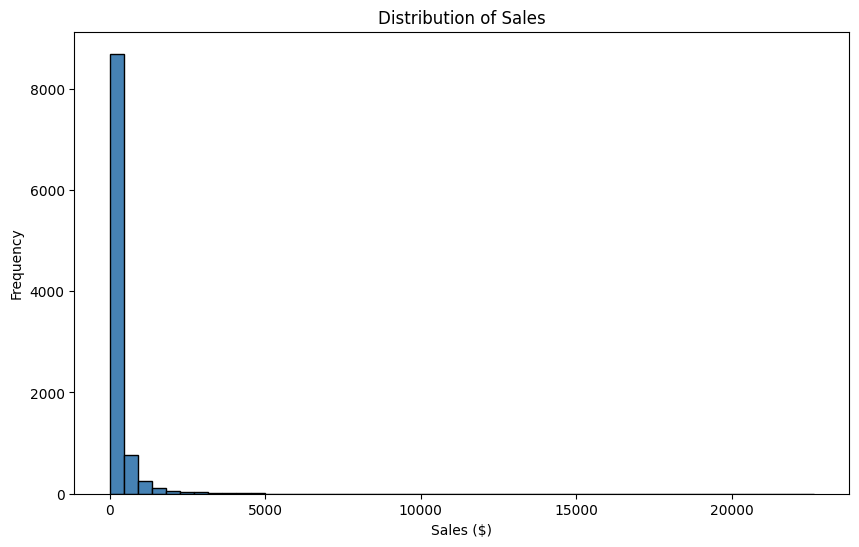

In [17]:
# Create a histogram to see distribution of Sales

plt.figure(figsize=(10, 6))

# Plot histogram
plt.hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')

# Add title and labels
plt.title('Distribution of Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')

# Show the plot
plt.show()

The sales distribution is right-skewed. Most values are low, while a few are very high. This means that large sales are rare but have a strong impact.

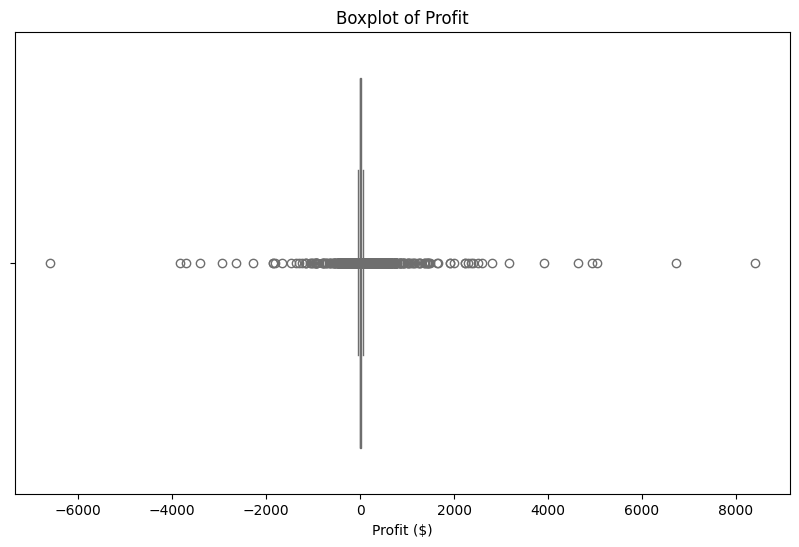

In [18]:
# Create a boxplot to analyze Profit distribution

plt.figure(figsize=(10, 6))

sns.boxplot(x=df['Profit'], color='lightcoral')

plt.title('Boxplot of Profit')
plt.xlabel('Profit ($)')

plt.show()

Most profit values are in the middle range. There are some outliers, which means a few transactions have very high profit or big losses.

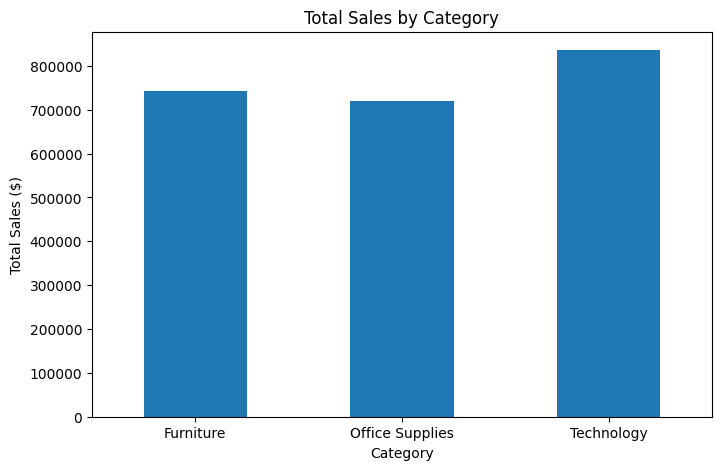

In [19]:
# Calculate total sales by Category
cat_sales = df.groupby('Category')['Sales'].sum()

# Plot bar chart
plt.figure(figsize=(8, 5))
cat_sales.plot(kind='bar')

# Add titles and labels
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')

plt.xticks(rotation=0)

plt.show()

Technology has the highest sales. Furniture and Office Supplies have lower sales.

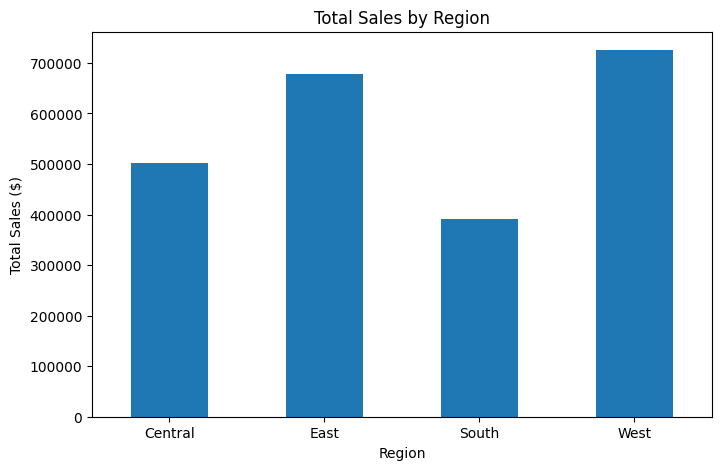

In [20]:
# Calculate total sales by Region
region_sales = df.groupby('Region')['Sales'].sum()

# Plot bar chart
plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar')

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)

plt.show()

The West region has the highest sales. Other regions have lower sales.

In [21]:
# Calculate Q1 and Q3
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

# Calculate boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Find outliers
outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]

print("Number of outliers:", len(outliers))

Q1: 1.72875
Q3: 29.364
IQR: 27.63525
Lower bound: -39.724125
Upper bound: 70.816875
Number of outliers: 1881


The West region has the highest sales. Other regions generate less revenue.

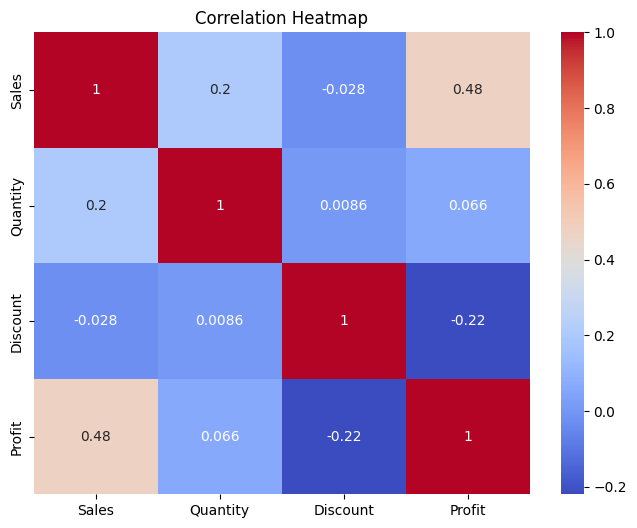

In [22]:
# Select numerical columns
numerical_cols = df[['Sales', 'Quantity', 'Discount', 'Profit']]

# Calculate correlation matrix
corr_matrix = numerical_cols.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

Sales and Profit are positively related. Discount and Profit are negatively related. Other relationships are weak.

/tmp/ipykernel_710/1441430868.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


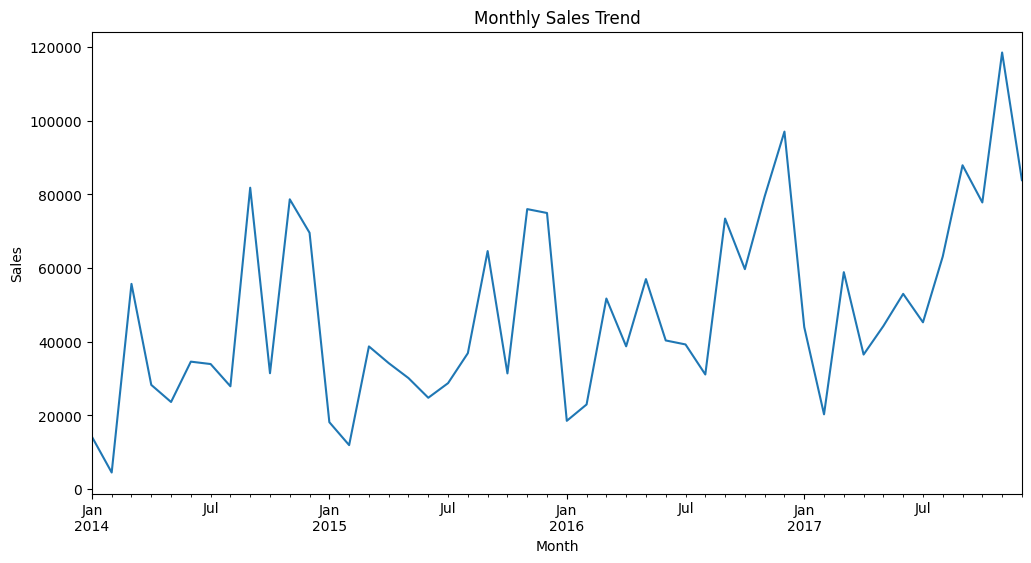

In [23]:
# Monthly sales trend
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

Sales increase over time with some peaks. The highest values appear at the end, possibly due to seasonal demand.